### Reqirements
- keras >= 2.2.0 or tensorflow >= 1.13
- segmenation-models==1.0.*
- albumentations==0.3.0

In [1]:
# Install required libs
### please update Albumentations to version>=0.3.0 for `Lambda` transform support
# !pip install -U albumentations>=0.3.0 --user 
# !pip install -U --pre segmentation-models --user

# Loading dataset

For this example we will use **CamVid** dataset. It is a set of:
 - **train** images + segmentation masks
 - **validation** images + segmentation masks
 - **test** images + segmentation masks
 
All images have 320 pixels height and 480 pixels width.
For more inforamtion about dataset visit http://mi.eng.cam.ac.uk/research/projects/VideoRec/CamVid/.

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_KERAS_DISABLE_TRACEBACK_FILTERING'] = '1'

import cv2
import keras
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

2025-02-08 23:18:57.975303: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739053137.991600 3952741 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739053137.996563 3952741 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-08 23:18:58.015470: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
os.getcwd()

'/mnt/bcache/work/a.omidvarnia/GIT_repositories/segmentation_models/examples'

In [4]:
DATA_DIR = './data/CamVid/'

# load repo with data if it is not exists
if not os.path.exists(DATA_DIR):
    print('Loading data...')
    os.system('git clone https://github.com/alexgkendall/SegNet-Tutorial ./data')
    print('Done!')

Loading data...


Cloning into './data'...


Done!


Updating files: 100% (1445/1445), done.


In [5]:
x_train_dir = os.path.join(DATA_DIR, 'train')
y_train_dir = os.path.join(DATA_DIR, 'trainannot')

x_valid_dir = os.path.join(DATA_DIR, 'val')
y_valid_dir = os.path.join(DATA_DIR, 'valannot')

x_test_dir = os.path.join(DATA_DIR, 'test')
y_test_dir = os.path.join(DATA_DIR, 'testannot')

# Dataloader and utility functions 

In [7]:
# helper function for data visualization
def visualize(**images):
    """PLot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(' '.join(name.split('_')).title())
        plt.imshow(image)
    plt.show()
    
# helper function for data visualization    
def denormalize(x):
    """Scale image to range 0..1 for correct plot"""
    x_max = np.percentile(x, 98)
    x_min = np.percentile(x, 2)    
    x = (x - x_min) / (x_max - x_min)
    x = x.clip(0, 1)
    return x

def ensure_numeric(generator):
    for x, y in generator:
        yield (tf.cast(x, tf.float32), tf.cast(y, tf.float32))
        
class Dataset:
    """CamVid Dataset. Read images, apply augmentation and preprocessing transformations.
    
    Args:
        images_dir (str): path to images folder
        masks_dir (str): path to segmentation masks folder
        classes (list): list of classes to extract from segmentation mask
        augmentation (albumentations.Compose): data transformation pipeline 
            (e.g. flip, scale, etc.)
        preprocessing (albumentations.Compose): data preprocessing 
            (e.g. normalization, shape manipulation, etc.)
    """
    
    CLASSES = ['sky', 'building', 'pole', 'road', 'pavement', 
               'tree', 'signsymbol', 'fence', 'car', 
               'pedestrian', 'bicyclist', 'unlabelled']
    
    def __init__(
            self, 
            images_dir, 
            masks_dir, 
            classes=None, 
            augmentation=None, 
            preprocessing=None,
    ):
        self.ids = os.listdir(images_dir)
        self.images_fps = [os.path.join(images_dir, image_id) for image_id in self.ids]
        self.masks_fps = [os.path.join(masks_dir, image_id) for image_id in self.ids]
        
        # convert str names to class values on masks
        self.class_values = [self.CLASSES.index(cls.lower()) for cls in classes] if classes else None
        
        self.augmentation = augmentation
        self.preprocessing = preprocessing
    
    def __getitem__(self, i):
        # read data
        image = cv2.imread(self.images_fps[i])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks_fps[i], 0)
        
        image = image.astype(np.float32) / 255.0  # Normalize to [0, 1]
        mask = mask.astype(np.float32)
        
        # extract certain classes from mask
        if self.class_values is not None:
            masks = [(mask == v) for v in self.class_values]
            mask = np.stack(masks, axis=-1).astype('float32')
        
            # add background if mask is not binary
            if mask.shape[-1] != 1:
                background = 1 - mask.sum(axis=-1, keepdims=True)
                mask = np.concatenate((mask, background), axis=-1)
        else:
            mask = np.expand_dims(mask, axis=-1)
        
        # apply augmentations
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        # apply preprocessing
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
            image = tf.cast(image, tf.float32)
            mask = tf.cast(mask, tf.float32)
            
        return image, mask
        
    def __len__(self):
        return len(self.ids)
    
class Dataloader(keras.utils.Sequence):
    """Load data from dataset and form batches
    
    Args:
        dataset: instance of Dataset class for image loading and preprocessing.
        batch_size: Integer number of images in batch.
        shuffle: Boolean, if `True` shuffle image indexes each epoch.
        input_image_shape (tuple): desired shape of the input images (height, width)
    """
    
    def __init__(self, dataset, batch_size=1, shuffle=False, input_image_shape=(320, 320)):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(dataset))
        self.input_image_shape = input_image_shape

        self.on_epoch_end()

    def __getitem__(self, i):
        # collect batch data
        start = i * self.batch_size
        stop = (i + 1) * self.batch_size
        data = []
        for j in range(start, stop):
            image, mask = self.dataset[j]
            
            data.append((image, mask))
        
        # transpose list of lists
        batch = [np.stack(samples, axis=0) for samples in zip(*data)]
        for item in batch:
            print(f"Shape: {item.shape}, dtype: {item.dtype}")
        return tuple(tf.convert_to_tensor(item) for item in batch)
            
    def __len__(self):
        """Denotes the number of batches per epoch"""
        return len(self.indexes) // self.batch_size
    
    def on_epoch_end(self):
        """Callback function to shuffle indexes each epoch"""
        if self.shuffle:
            self.indexes = np.random.permutation(self.indexes)


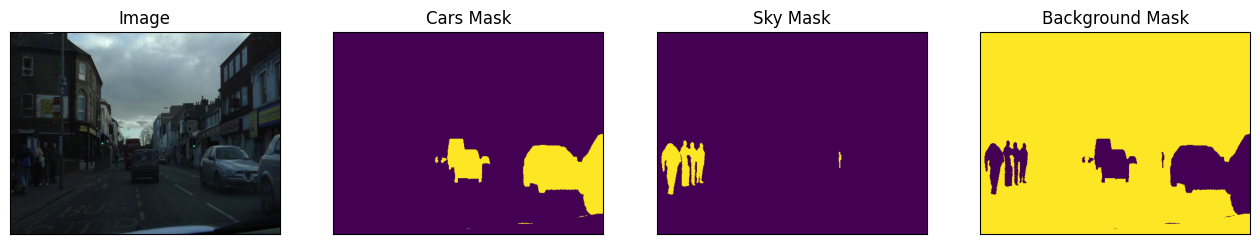

In [8]:
# Lets look at data we have
dataset = Dataset(x_train_dir, y_train_dir, classes=['car', 'pedestrian'])

image, mask = dataset[5] # get some sample
visualize(
    image=image, 
    cars_mask=mask[..., 0].squeeze(),
    sky_mask=mask[..., 1].squeeze(),
    background_mask=mask[..., 2].squeeze(),
)

### Augmentations

Data augmentation is a powerful technique to increase the amount of your data and prevent model overfitting.  
If you not familiar with such trick read some of these articles:
 - [The Effectiveness of Data Augmentation in Image Classification using Deep
Learning](http://cs231n.stanford.edu/reports/2017/pdfs/300.pdf)
 - [Data Augmentation | How to use Deep Learning when you have Limited Data](https://medium.com/nanonets/how-to-use-deep-learning-when-you-have-limited-data-part-2-data-augmentation-c26971dc8ced)
 - [Data Augmentation Experimentation](https://towardsdatascience.com/data-augmentation-experimentation-3e274504f04b)

Since our dataset is very small we will apply a large number of different augmentations:
 - horizontal flip
 - affine transforms
 - perspective transforms
 - brightness/contrast/colors manipulations
 - image bluring and sharpening
 - gaussian noise
 - random crops

All this transforms can be easily applied with [**Albumentations**](https://github.com/albu/albumentations/) - fast augmentation library.
For detailed explanation of image transformations you can look at [kaggle salt segmentation exmaple](https://github.com/albu/albumentations/blob/master/notebooks/example_kaggle_salt.ipynb) provided by [**Albumentations**](https://github.com/albu/albumentations/) authors.


In [9]:
import albumentations as A

/mnt/bcache/work/a.omidvarnia/GIT_repositories/segmentation_models/unet_sm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
def round_clip_0_1(x, **kwargs):
    return x.round().clip(0, 1)

# define heavy augmentations
def get_training_augmentation():
    train_transform = [

        A.HorizontalFlip(p=0.5),

        A.ShiftScaleRotate(scale_limit=0.5, rotate_limit=0, shift_limit=0.1, p=1, border_mode=0),

        A.PadIfNeeded(min_height=320, min_width=320, border_mode=0),
        A.RandomCrop(height=320, width=320),

        A.OneOf(
            [
                A.CLAHE(p=1),
                A.RandomGamma(p=1),
            ],
            p=0.9,
        ),

        A.OneOf(
            [
                A.Blur(blur_limit=3, p=1),
                A.MotionBlur(blur_limit=3, p=1),
            ],
            p=0.9,
        ),

        A.OneOf(
            [
                A.HueSaturationValue(p=1),
            ],
            p=0.9,
        ),
        A.Lambda(mask=round_clip_0_1)
    ]
    return A.Compose(train_transform)


def get_validation_augmentation():
    """Add paddings to make image shape divisible by 32"""
    test_transform = [
        A.PadIfNeeded(384, 480)
    ]
    return A.Compose(test_transform)

def get_preprocessing(preprocessing_fn):
    """Construct preprocessing transform
    
    Args:
        preprocessing_fn (callbale): data normalization function 
            (can be specific for each pretrained neural network)
    Return:
        transform: albumentations.Compose
    
    """
    
    _transform = [
        A.Lambda(image=preprocessing_fn),
    ]
    return A.Compose(_transform)

/mnt/bcache/work/a.omidvarnia/GIT_repositories/segmentation_models/unet_sm/lib/python3.11/site-packages/albumentations/core/validation.py:58: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


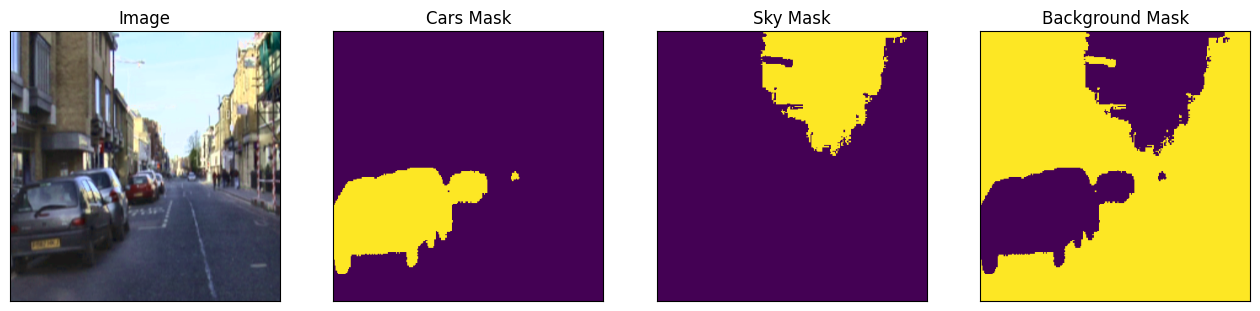

In [11]:
# Lets look at augmented data we have
dataset = Dataset(x_train_dir, y_train_dir, classes=['car', 'sky'], augmentation=get_training_augmentation())

image, mask = dataset[12] # get some sample
visualize(
    image=image, 
    cars_mask=mask[..., 0].squeeze(),
    sky_mask=mask[..., 1].squeeze(),
    background_mask=mask[..., 2].squeeze(),
)

# Segmentation model training

In [12]:
# %pip install segmentation-models
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"

import segmentation_models as sm

# segmentation_models could also use `tf.keras` if you do not have Keras installed
# or you could switch to other framework using `sm.set_framework('tf.keras')`
sm.set_framework('tf.keras')

Segmentation Models: using `tf.keras` framework.


In [13]:
BACKBONE = 'efficientnetb3'
BATCH_SIZE = 8
CLASSES = ['car']
LR = 0.0001
EPOCHS = 40

preprocess_input = sm.get_preprocessing(BACKBONE)

In [14]:
# define network parameters
n_classes = 1 if len(CLASSES) == 1 else (len(CLASSES) + 1)  # case for binary and multiclass segmentation
activation = 'sigmoid' if n_classes == 1 else 'softmax'

#create model
model = sm.Unet(BACKBONE, classes=n_classes, activation=activation)
print(model.input_shape, model.output_shape)

I0000 00:00:1739053274.123823 3952741 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22384 MB memory:  -> device: 0, name: NVIDIA A30, pci bus id: 0000:81:00.0, compute capability: 8.0


(None, None, None, 3) (None, None, None, 1)


In [15]:
# define optomizer
optim = keras.optimizers.Adam(LR)

# Segmentation models losses can be combined together by '+' and scaled by integer or float factor
dice_loss = sm.losses.DiceLoss()
focal_loss = sm.losses.BinaryFocalLoss() if n_classes == 1 else sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)

# actulally total_loss can be imported directly from library, above example just show you how to manipulate with losses
total_loss = sm.losses.binary_focal_dice_loss # or sm.losses.categorical_focal_dice_loss 

metrics = [sm.metrics.IOUScore(threshold=0.5), sm.metrics.FScore(threshold=0.5)]
metrics = [sm.metrics.IOUScore(threshold=0.5)]
metrics=['accuracy', sm.metrics.IOUScore(threshold=0.5)]

from tensorflow.keras.metrics import MeanIoU
metrics=[MeanIoU(num_classes=2)]
metrics=['accuracy']

# compile keras model with defined optimozer, loss and metrics
model.compile(optim, total_loss, metrics)

In [ ]:
# print(f"{train_dataset.__len__()} {valid_dataset.__len__()}")
# print(f"{train_dataset.__len__() // BATCH_SIZE} {valid_dataset.__len__() // 1}")
# print(f"training folder: {x_train_dir}")
# print(f"validation folder: {x_valid_dir}")
# print(f"training annotation folder: {y_train_dir}")
# print(f"validation annotation folder: {y_valid_dir}")



NameError: name 'train_dataset' is not defined

In [17]:
# Dataset for train images
train_dataset = Dataset(
    x_train_dir, 
    y_train_dir, 
    classes=CLASSES, 
    augmentation=get_training_augmentation(),
    preprocessing=get_preprocessing(preprocess_input),
)

# Dataset for validation images
valid_dataset = Dataset(
    x_valid_dir, 
    y_valid_dir, 
    classes=CLASSES, 
    augmentation=get_validation_augmentation(),
    preprocessing=get_preprocessing(preprocess_input),
)

train_dataloader = Dataloader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = Dataloader(valid_dataset, batch_size=1, shuffle=False)

# check shapes for errors
assert train_dataloader[0][0].shape == (BATCH_SIZE, 320, 320, 3)
assert train_dataloader[0][1].shape == (BATCH_SIZE, 320, 320, n_classes)

# Ensure that the image size of the train_dataloader and valid_dataloader are the same
# assert train_dataloader[0][0].shape == valid_dataloader[0][0].shape, "The image size of the train_dataloader and valid_dataloader are not the same"

# define callbacks for learning rate scheduling and best checkpoints saving
callbacks = [
    keras.callbacks.ModelCheckpoint('./best_model.weights.h5', save_weights_only=True, save_best_only=True, mode='min'),
    keras.callbacks.ReduceLROnPlateau(),
]

/mnt/bcache/work/a.omidvarnia/GIT_repositories/segmentation_models/unet_sm/lib/python3.11/site-packages/albumentations/core/validation.py:58: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32


In [20]:
# print(train_dataset[0][0].shape, train_dataset[0][1].shape) 
# print(valid_dataset[0][0].shape, valid_dataset[0][1].shape)

# Ensure that the images and masks are numpy arrays before resizing
train_images, train_masks = train_dataloader[0]
# valid_images, valid_masks = valid_dataloader[0]
valid_images = train_images[:int(0.3 * len(train_images))]
valid_masks = train_masks[:int(0.3 * len(train_masks))]

print(train_images.shape, train_masks.shape)
print(valid_images.shape, valid_masks.shape)

Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
(8, 320, 320, 3) (8, 320, 320, 1)
(2, 320, 320, 3) (2, 320, 320, 1)


In [ ]:
# Check if the images inside train_dataloader are compatible with keras
for x, y in train_dataloader:
    
    # Check if the images are compatible with keras
    assert x.shape == (BATCH_SIZE, 320, 320, 3), f"Expected (BATCH_SIZE, 320, 320, 3), but got {x.shape}"
    assert y.shape == (BATCH_SIZE, 320, 320, n_classes), f"Expected (BATCH_SIZE, 320, 320, n_classes), but got {y.shape}"
    
    # Check data types
    assert x.dtype == tf.float32, f"Expected tf.float32, but got {x.dtype}"
    assert y.dtype == tf.float32,  f"Expected tf.float32, but got {y.dtype}"
    
# # The same for valid_dataloader
# for x, y in valid_dataloader:
    
#     # Check if the images are compatible with keras
#     assert x.shape == (1, 320, 320, 3), f"Expected (1, 384, 480, 3), but got {x.shape}"
#     assert y.shape == (1, 320, 320), f"Expected (1, 384, 480, n_classes), but got {y.shape}"
    
#     # Check data types
#     assert x.dtype == tf.float32, f"Expected tf.float32, but got {x.dtype}"
#     assert y.dtype == tf.float32,  f"Expected tf.float32, but got {y.dtype}"
    



Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32


AssertionError: Expected (1, 384, 480, 3), but got (1, 384, 480, 3)

In [22]:
# train model
history = model.fit(
    train_dataloader, 
    steps_per_epoch=len(train_dataloader), 
    epochs=EPOCHS, 
    callbacks=callbacks, 
    validation_data=valid_dataloader, 
    validation_steps=len(valid_dataloader),
)

/mnt/bcache/work/a.omidvarnia/GIT_repositories/segmentation_models/unet_sm/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Shape: (8, 320, 320, 3), dtype: float32
Shape: (8, 320, 320, 1), dtype: float32
Epoch 1/40


ValueError: dtype='string' is not a valid dtype for Keras type promotion.

In [ ]:
# Plot training & validation iou_score values
plt.figure(figsize=(30, 5))
plt.subplot(121)
plt.plot(history.history['iou_score'])
plt.plot(history.history['val_iou_score'])
plt.title('Model iou_score')
plt.ylabel('iou_score')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(122)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Model Evaluation

In [26]:
test_dataset = Dataset(
    x_test_dir, 
    y_test_dir, 
    classes=CLASSES, 
    augmentation=get_validation_augmentation(),
    preprocessing=get_preprocessing(preprocess_input),
)

test_dataloader = Dataloader(test_dataset, batch_size=1, shuffle=False)

In [28]:
# load best weights
model.load_weights('best_model.h5') 

In [ ]:
scores = model.evaluate_generator(test_dataloader)

print("Loss: {:.5}".format(scores[0]))
for metric, value in zip(metrics, scores[1:]):
    print("mean {}: {:.5}".format(metric.__name__, value))

# Visualization of results on test dataset

In [ ]:
n = 5
ids = np.random.choice(np.arange(len(test_dataset)), size=n)

for i in ids:
    
    image, gt_mask = test_dataset[i]
    image = np.expand_dims(image, axis=0)
    pr_mask = model.predict(image).round()
    
    visualize(
        image=denormalize(image.squeeze()),
        gt_mask=gt_mask[..., 0].squeeze(),
        pr_mask=pr_mask[..., 0].squeeze(),
    )